# IKP Benchmark Results

Summary of all models tested with [IKP](https://github.com/19PINE-AI/ikp).

Re-run this notebook at any time to pick up new results from `/tmp/ikp_*.log`.

In [1]:
import re, glob
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from IPython.display import display
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)


## Load results

In [2]:
LOG_MAP = {
    "/tmp/ikp_full.log":                        "Qwen2.5-VL-7B-FP8",
    "/tmp/ikp_thinking.log":                    "Qwen2.5-VL-7B-FP8 (+think)",
    "/tmp/ikp_bf16.log":                        "Qwen2.5-VL-7B-BF16",
    "/tmp/ikp_nvfp4.log":                       "Qwen2.5-VL-7B-NVFP4",
    "/tmp/ikp_14b.log":                         "Qwen2.5-14B-BF16",
    "/tmp/ikp_Qwen-Qwen3-6-35B-A3B.log":       "Qwen3.6-35B-A3B (MoE)",
    "/tmp/ikp_Qwen-Qwen3-6-35B-A3B-FP8.log":  "Qwen3.6-35B-A3B-FP8 (MoE)",
    "/tmp/ikp_Qwen-Qwen3-6-27B.log":           "Qwen3.6-27B",
    "/tmp/ikp_Qwen-Qwen3-6-27B-FP8.log":       "Qwen3.6-27B-FP8",
    "/tmp/ikp_deepseek-ai-DeepSeek-V4-Flash.log":        "DeepSeek-V4-Flash",
    "/tmp/ikp_moonshotai-Kimi-VL-A3B-Instruct.log":      "Kimi-VL-A3B",
    "/tmp/ikp_nvidia-Qwen3-5-397B-A17B-NVFP4.log":       "Qwen3.5-397B-A17B-NVFP4 (MoE)",
    "/tmp/ikp_AEON-7-Qwen3-6-35B-A3B-heretic-NVFP4.log": "Qwen3.6-35B-heretic-NVFP4",
}

ACTUAL_PARAMS = {
    "Qwen2.5-VL-7B-FP8":               "7B",
    "Qwen2.5-VL-7B-FP8 (+think)":      "7B",
    "Qwen2.5-VL-7B-BF16":              "7B",
    "Qwen2.5-VL-7B-NVFP4":             "7B",
    "Qwen2.5-14B-BF16":                "14B",
    "Qwen3.6-35B-A3B (MoE)":           "35B/3B",
    "Qwen3.6-35B-A3B-FP8 (MoE)":       "35B/3B",
    "Qwen3.6-27B":                      "27B",
    "Qwen3.6-27B-FP8":                  "27B",
    "DeepSeek-V4-Flash":                "?",
    "Kimi-VL-A3B":                      "~3B",
    "Qwen3.5-397B-A17B-NVFP4 (MoE)":  "397B/17B",
    "Qwen3.6-35B-heretic-NVFP4":        "35B/3B",
}

TIERS = ["T1", "T2", "T3", "T4", "T5", "T6", "T7"]

def parse_log(path):
    try:
        text = Path(path).read_text()
    except FileNotFoundError:
        return None
    if "Estimated size:" not in text:
        return None
    out = {}
    m = re.search(r"Accuracy:\s+([\d.]+)%\s+\(penalized\)\s+([\d.]+)%\s+\(raw\)", text)
    if m:
        out["penalized"] = float(m.group(1))
        out["raw"]       = float(m.group(2))
    m = re.search(r"Estimated size:\s+(\S+)", text)
    out["estimated"] = m.group(1) if m else "N/A"
    tiers = {}
    for line in text.splitlines():
        tm = re.match(r"\s*(T\d)\s+(\d+)%\s+(\d+)\s+(\d+)\s+(\d+)\s+(\d+)", line)
        if tm:
            t, acc, cor, wrg, ref, tot = tm.groups()
            tiers[t] = {
                "penalized": int(acc),
                "raw": round(int(cor)/int(tot)*100, 1) if int(tot) else 0,
                "correct": int(cor), "wrong": int(wrg),
                "refusal": int(ref), "total": int(tot),
            }
    out["tiers"] = tiers
    return out

results = {}
for log_path, model_name in LOG_MAP.items():
    data = parse_log(log_path)
    if data:
        results[model_name] = data

print(f"Loaded {len(results)} model results:")
for name, d in results.items():
    print(f"  {name:45s}  estimated={d.get('estimated','?'):6s}  penalized={d.get('penalized',0):.1f}%")


Loaded 9 model results:
  Qwen2.5-VL-7B-FP8                              estimated=7B      penalized=26.1%
  Qwen2.5-VL-7B-FP8 (+think)                     estimated=8B      penalized=26.1%
  Qwen2.5-VL-7B-BF16                             estimated=7B      penalized=26.1%
  Qwen2.5-VL-7B-NVFP4                            estimated=8B      penalized=26.6%
  Qwen2.5-14B-BF16                               estimated=16B     penalized=30.8%
  Qwen3.6-35B-A3B (MoE)                          estimated=38B     penalized=36.4%
  Qwen3.6-35B-A3B-FP8 (MoE)                      estimated=46B     penalized=37.7%
  Qwen3.6-27B                                    estimated=36B     penalized=36.1%
  Qwen3.6-27B-FP8                                estimated=37B     penalized=36.4%


## Summary table

Color scale: 🟩 ≥80% · 🟨 20–50% · 🟥 0%

In [3]:
# ── Summary DataFrame ─────────────────────────────────────────
rows = []
for model, d in results.items():
    row = {
        "Model": model,
        "Actual": ACTUAL_PARAMS.get(model, "?"),
        "Estimated": d.get("estimated", "N/A"),
        "Penalized Acc": d.get("penalized", 0),
        "Raw Acc": d.get("raw", 0),
    }
    for t in TIERS:
        row[t] = d["tiers"].get(t, {}).get("penalized", 0)
    rows.append(row)

df = pd.DataFrame(rows).set_index("Model")

# Color the summary table
def color_acc(val):
    if val >= 80:  return "background-color: #2ecc71; color: white"
    if val >= 50:  return "background-color: #27ae60; color: white"
    if val >= 20:  return "background-color: #f39c12; color: white"
    if val > 0:    return "background-color: #e67e22; color: white"
    return "background-color: #e74c3c; color: white"

def color_tier(val):
    if val >= 80:  return "background-color: #1a9850"
    if val >= 50:  return "background-color: #66bd63"
    if val >= 20:  return "background-color: #fee08b"
    if val > 0:    return "background-color: #f46d43"
    return "background-color: #d73027"

styled = (df.style
    .format("{:.1f}%", subset=["Penalized Acc", "Raw Acc"] + TIERS)
    .map(color_acc, subset=["Penalized Acc", "Raw Acc"])
    .map(color_tier, subset=TIERS)
    .set_caption("IKP Benchmark — all models (self-judge, 2026-04-30)")
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold")]},
        {"selector": "th", "props": [("background-color", "#2c3e50"), ("color", "white"), ("padding", "6px 10px")]},
        {"selector": "td", "props": [("padding", "4px 10px"), ("text-align", "center")]},
    ])
)
display(styled)


,Actual,Estimated,Penalized Acc,Raw Acc,T1,T2,T3,T4,T5,T6,T7
Model,,,,,,,,,,,
Qwen2.5-VL-7B-FP8,7B,7B,26.1%,39.3%,96.0%,86.0%,0.0%,0.0%,0.0%,0.0%,0.0%
Qwen2.5-VL-7B-FP8 (+think),7B,8B,26.1%,39.3%,98.0%,85.0%,0.0%,0.0%,0.0%,0.0%,0.0%
Qwen2.5-VL-7B-BF16,7B,7B,26.1%,38.1%,97.0%,86.0%,0.0%,0.0%,0.0%,0.0%,0.0%
Qwen2.5-VL-7B-NVFP4,7B,8B,26.6%,36.5%,97.0%,80.0%,8.0%,0.0%,0.0%,0.0%,0.0%
Qwen2.5-14B-BF16,14B,16B,30.8%,42.0%,96.0%,90.0%,30.0%,0.0%,0.0%,0.0%,0.0%
Qwen3.6-35B-A3B (MoE),35B/3B,38B,36.4%,49.3%,99.0%,96.0%,60.0%,0.0%,0.0%,0.0%,0.0%
Qwen3.6-35B-A3B-FP8 (MoE),35B/3B,46B,37.7%,50.0%,99.0%,100.0%,64.0%,2.0%,0.0%,0.0%,0.0%
Qwen3.6-27B,27B,36B,36.1%,48.4%,98.0%,96.0%,59.0%,0.0%,0.0%,0.0%,0.0%
Qwen3.6-27B-FP8,27B,37B,36.4%,48.0%,98.0%,98.0%,58.0%,0.0%,0.0%,0.0%,0.0%


## Tier heatmap (penalized accuracy)

Penalized score = `max(0, (correct − wrong) / total)`. Wrong answers cost −1.

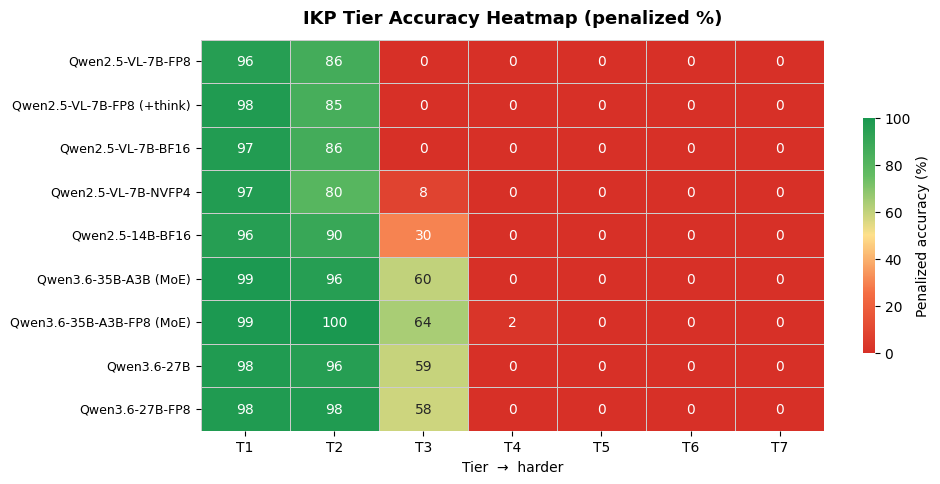

In [4]:
# ── Tier accuracy heatmap (penalized %) ───────────────────────
heat_data = pd.DataFrame(
    {model: [d["tiers"].get(t, {}).get("penalized", 0) for t in TIERS]
     for model, d in results.items()},
    index=TIERS
).T

fig, ax = plt.subplots(figsize=(10, max(4, len(heat_data) * 0.55)))

# Custom colormap: dark red (0%) → yellow (50%) → green (100%)
cmap = mcolors.LinearSegmentedColormap.from_list(
    "ikp", ["#d73027", "#f46d43", "#fee08b", "#66bd63", "#1a9850"]
)

sns.heatmap(
    heat_data, annot=True, fmt=".0f", cmap=cmap,
    vmin=0, vmax=100, linewidths=0.5, linecolor="#cccccc",
    cbar_kws={"label": "Penalized accuracy (%)", "shrink": 0.6},
    ax=ax
)
ax.set_title("IKP Tier Accuracy Heatmap (penalized %)", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Tier  →  harder", fontsize=10)
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
plt.savefig(Path("/localhome/swqa/workspace/just_for_exp/ikp_study/results/heatmap_penalized.png"),
            dpi=150, bbox_inches="tight")
plt.show()


## Tier heatmap (raw accuracy)

Raw = `correct / total`, no penalty.

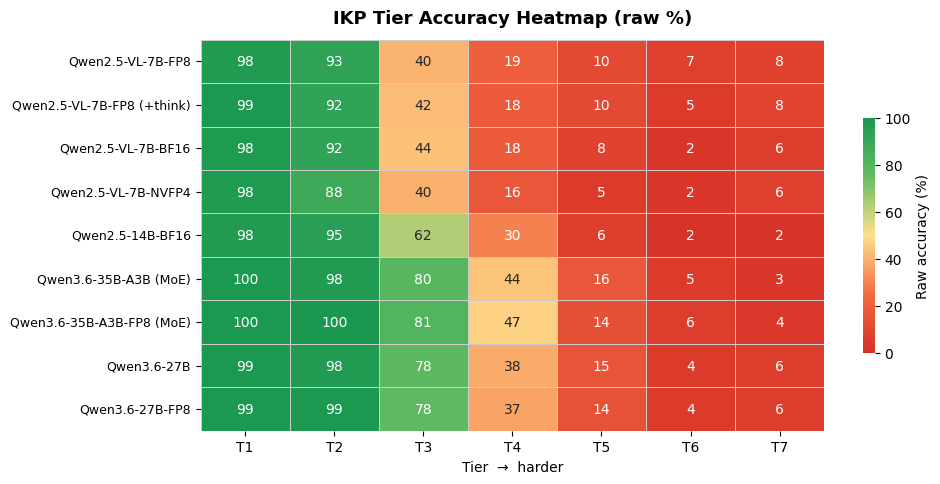

In [5]:
# ── Tier accuracy heatmap (raw %) ─────────────────────────────
heat_raw = pd.DataFrame(
    {model: [d["tiers"].get(t, {}).get("raw", 0) for t in TIERS]
     for model, d in results.items()},
    index=TIERS
).T

fig, ax = plt.subplots(figsize=(10, max(4, len(heat_raw) * 0.55)))
cmap = mcolors.LinearSegmentedColormap.from_list(
    "ikp", ["#d73027", "#f46d43", "#fee08b", "#66bd63", "#1a9850"]
)
sns.heatmap(
    heat_raw, annot=True, fmt=".0f", cmap=cmap,
    vmin=0, vmax=100, linewidths=0.5, linecolor="#cccccc",
    cbar_kws={"label": "Raw accuracy (%)", "shrink": 0.6},
    ax=ax
)
ax.set_title("IKP Tier Accuracy Heatmap (raw %)", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Tier  →  harder", fontsize=10)
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
plt.show()


## Overall penalized accuracy

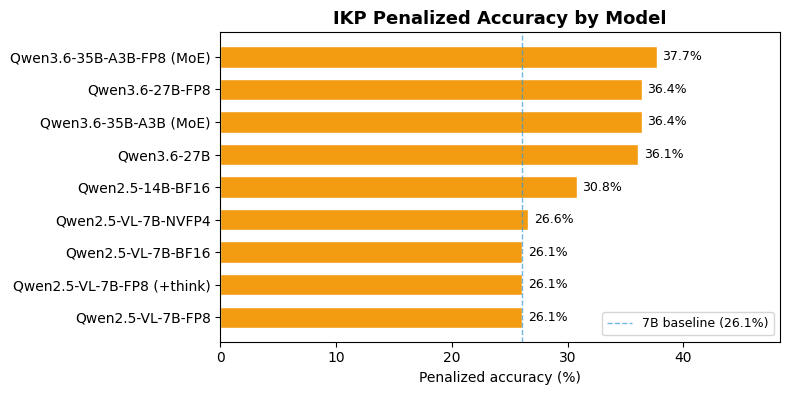

In [6]:
# ── Penalized accuracy bar chart ──────────────────────────────
order = df["Penalized Acc"].sort_values(ascending=True)
colors = ["#2ecc71" if v >= 40 else "#f39c12" if v >= 25 else "#e74c3c" for v in order]

fig, ax = plt.subplots(figsize=(8, max(4, len(order) * 0.45)))
bars = ax.barh(order.index, order.values, color=colors, edgecolor="white", height=0.65)
ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=9)
ax.set_xlabel("Penalized accuracy (%)")
ax.set_xlim(0, max(order.values) * 1.15 + 5)
ax.set_title("IKP Penalized Accuracy by Model", fontsize=13, fontweight="bold")
ax.axvline(26.1, color="#3498db", linestyle="--", linewidth=1, alpha=0.7, label="7B baseline (26.1%)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## T3 & T4 verdict breakdown

T3 (7B–32B) and T4 (32B–235B) are the most diagnostic tiers — this is where models either start knowing things or start confidently hallucinating.

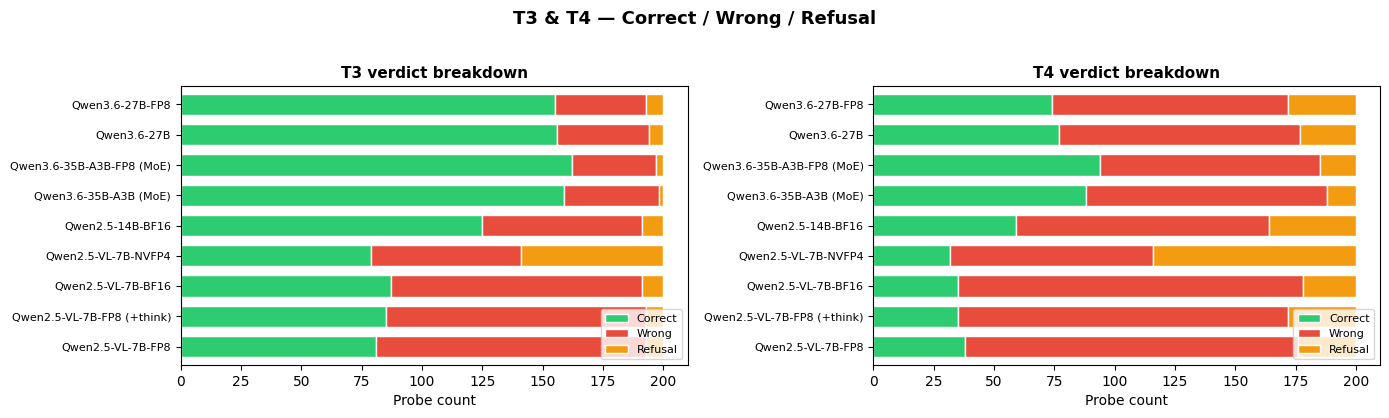

In [7]:
# ── Correct / Wrong / Refusal breakdown for T3 & T4 ──────────
fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(results) * 0.45)))

for ax, tier in zip(axes, ["T3", "T4"]):
    rows_v = []
    for model, d in results.items():
        t = d["tiers"].get(tier, {})
        rows_v.append({
            "Model": model,
            "Correct": t.get("correct", 0),
            "Wrong":   t.get("wrong", 0),
            "Refusal": t.get("refusal", 0),
        })
    dv = pd.DataFrame(rows_v).set_index("Model")
    dv = dv.loc[dv.sum(axis=1) > 0]  # drop models that didn't run this tier
    dv.plot(kind="barh", stacked=True, ax=ax,
            color=["#2ecc71", "#e74c3c", "#f39c12"],
            width=0.7, edgecolor="white")
    ax.set_title(f"{tier} verdict breakdown", fontsize=11, fontweight="bold")
    ax.set_xlabel("Probe count")
    ax.set_ylabel("")
    ax.legend(loc="lower right", fontsize=8)
    ax.tick_params(axis="y", labelsize=8)

plt.suptitle("T3 & T4 — Correct / Wrong / Refusal", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
